# Automated Seizure Detection — C9orf72-KO vs WT Mice

**Model:** C9orf72 knockout (C9-KO) — genetic model of ALS/FTD  
**Recording:** 4h post kainic acid injection (2 × 2h ABF files per mouse)  
**Channel:** CA3 hippocampus (Ch0)

**Groups:**
- WT: 8 mice (16 ABF files, consecutive pairs)
- KO: 9 mice (18 ABF files, consecutive pairs)

**Detection pipeline:**
1. Load and concatenate both 2h recordings per mouse
2. Artifact rejection (voltage range filtering)
3. Adaptive baseline estimation (97th percentile)
4. IED detection (brief <200ms high-amplitude transients)
5. Seizure detection (sustained IED clusters >5 seconds)
6. Per-mouse metric computation

**Metrics:**

| Metric | Description |
|--------|-------------|
| IED rate | Interictal discharges per minute |
| Seizure count | Number of sustained ictal events |
| Seizure burden | % of recording time in seizure |
| Mean seizure duration | Average ictal event length (seconds) |
| First seizure latency | Time to first seizure (minutes) |
| Inter-IED interval | Mean time between discharges (seconds) |

---

## 0. Setup

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

sys.path.insert(0, os.path.join("..", "src"))

from utils import PATHS, COLORS, PLT_STYLE, check_paths
from seizure_detection import (
    pair_files,
    process_group,
    plot_eeg_with_events,
    plot_group_comparison,
)

plt.rcParams.update(PLT_STYLE)
FIGURES_DIR = os.path.join("..", "figures")
DATA_DIR = os.path.join("..", "data", "processed")
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

WT_DIR = PATHS["4m_KA"]["WT"]
KO_DIR = PATHS["4m_KA"]["KO"]

check_paths()
print("No animals excluded.")

Checking data paths:
  3m: WT=OK | KO=OK
  4m_KA: WT=OK | KO=OK
  6m: WT=OK | KO=OK
  12m: WT=OK | KO=OK
All paths OK.
No animals excluded.


## 1. Verify file pairing

In [2]:
wt_pairs = pair_files(WT_DIR)
ko_pairs = pair_files(KO_DIR)

print(f"WT mice: {len(wt_pairs)}")
for i, (f1, f2) in enumerate(wt_pairs):
    print(f"  Mouse {i+1}: {f1} + {f2}")

print(f"\nKO mice: {len(ko_pairs)}")
for i, (f1, f2) in enumerate(ko_pairs):
    print(f"  Mouse {i+1}: {f1} + {f2}")

WT mice: 8
  Mouse 1: 21507001.abf + 21507002.abf
  Mouse 2: 21513008.abf + 21513009.abf
  Mouse 3: 21517010.abf + 21517011.abf
  Mouse 4: 21518009.abf + 21518010.abf
  Mouse 5: 21519009.abf + 21519010.abf
  Mouse 6: 21520008.abf + 21520009.abf
  Mouse 7: 21521001.abf + 21521002.abf
  Mouse 8: 21521009.abf + 21521010.abf

KO mice: 9
  Mouse 1: 21508005.abf + 21508006.abf
  Mouse 2: 21510001.abf + 21510002.abf
  Mouse 3: 21511008.abf + 21511009.abf
  Mouse 4: 21512009.abf + 21512010.abf
  Mouse 5: 21514002.abf + 21514003.abf
  Mouse 6: 21514006.abf + 21514007.abf
  Mouse 7: 21517001.abf + 21517002.abf
  Mouse 8: 21518008.abf + 21518009.abf
  Mouse 9: 21519008.abf + 21519009.abf


## 2. Process all mice — WT and KO

Runs the full detection pipeline on every mouse.
**Note:** Takes 5–10 minutes depending on file size.

In [3]:
print("Processing WT mice...")
summary_wt, details_wt = process_group(WT_DIR, group="WT", channel=0)

print("\nProcessing KO mice...")
summary_ko, details_ko = process_group(KO_DIR, group="KO", channel=0)

print(f"\nWT: {len(summary_wt)} mice processed")
print(f"KO: {len(summary_ko)} mice processed")
print("\nWT summary:")
print(summary_wt[["mouse_id", "n_ieds", "ied_rate_per_min",
                   "n_seizures", "seizure_burden_pct"]].to_string(index=False))
print("\nKO summary:")
print(summary_ko[["mouse_id", "n_ieds", "ied_rate_per_min",
                   "n_seizures", "seizure_burden_pct"]].to_string(index=False))

Processing WT mice...
  8 mice found in WT
  Processing mouse 1/8: 2150700 (21507001.abf + 21507002.abf)
    IEDs: 8585 | Rate: 35.77/min | Seizures: 183 | Burden: 20.00%
  Processing mouse 2/8: 2151300 (21513008.abf + 21513009.abf)
    IEDs: 5477 | Rate: 22.82/min | Seizures: 73 | Burden: 9.62%
  Processing mouse 3/8: 2151701 (21517010.abf + 21517011.abf)
    IEDs: 12 | Rate: 0.05/min | Seizures: 0 | Burden: 0.00%
  Processing mouse 4/8: 2151800 (21518009.abf + 21518010.abf)
    IEDs: 0 | Rate: 0.00/min | Seizures: 0 | Burden: 0.00%
  Processing mouse 5/8: 2151900 (21519009.abf + 21519010.abf)
    IEDs: 814 | Rate: 3.39/min | Seizures: 19 | Burden: 0.91%
  Processing mouse 6/8: 2152000 (21520008.abf + 21520009.abf)
    IEDs: 3439 | Rate: 14.33/min | Seizures: 92 | Burden: 12.43%
  Processing mouse 7/8: 2152100 (21521001.abf + 21521002.abf)
    IEDs: 3592 | Rate: 14.97/min | Seizures: 77 | Burden: 7.57%
  Processing mouse 8/8: 2152100 (21521009.abf + 21521010.abf)
    IEDs: 0 | Rate: 0

## 3. Example EEG trace with detected events

Shows IEDs (red dots) and seizures (green shading) on a representative recording.

Saved: ..\figures\eeg_example_ko.png


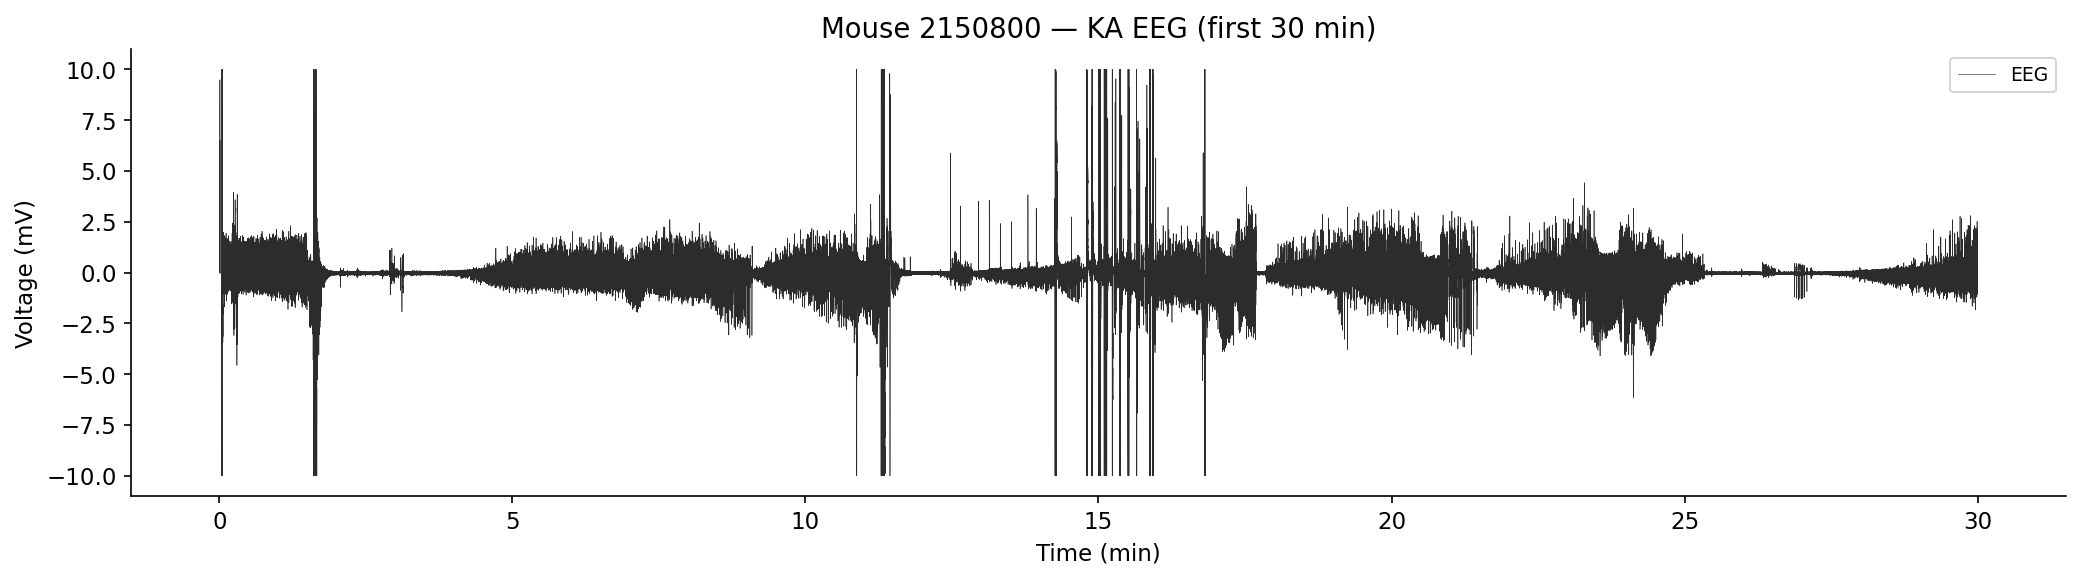

Mouse 2150800: 0 IEDs | 0 seizures


In [4]:
# Plot first KO mouse
f1, f2 = ko_pairs[0]
mouse_id = summary_ko["mouse_id"].iloc[0]
ieds_ex = details_ko[mouse_id]["ieds"]
seizures_ex = details_ko[mouse_id]["seizures"]

plot_eeg_with_events(
    os.path.join(KO_DIR, f1),
    os.path.join(KO_DIR, f2),
    ieds_ex, seizures_ex,
    mouse_id=mouse_id,
    plot_duration_min=30,
    save_path=os.path.join(FIGURES_DIR, "eeg_example_ko.png")
)
print(f"Mouse {mouse_id}: {len(ieds_ex)} IEDs | {len(seizures_ex)} seizures")

## 4. Group comparisons — all metrics

Mann-Whitney U test (two-sided) for each metric.
Statistical unit = one mouse.

In [5]:
metrics_to_compare = [
    ("ied_rate_per_min", "IED rate (events/min)"),
    ("n_seizures", "Seizure count"),
    ("seizure_burden_pct", "Seizure burden (%)"),
    ("mean_seizure_dur_s", "Mean seizure duration (s)"),
    ("first_seizure_min", "First seizure latency (min)"),
    ("mean_ied_interval_s", "Mean IED interval (s)"),
]

print(f"{'Metric':<35} {'WT mean±SEM':<22} {'KO mean±SEM':<22} {'p-value':<10} sig")
print("-" * 92)

stat_results = {}
for col, label in metrics_to_compare:
    wt_vals = summary_wt[col].dropna()
    ko_vals = summary_ko[col].dropna()
    if len(wt_vals) < 2 or len(ko_vals) < 2:
        continue
    stat, pval = mannwhitneyu(wt_vals, ko_vals, alternative="two-sided")
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"
    stat_results[col] = {"pval": pval, "sig": sig}
    wt_str = f"{wt_vals.mean():.3f}±{wt_vals.sem():.3f}"
    ko_str = f"{ko_vals.mean():.3f}±{ko_vals.sem():.3f}"
    print(f"{label:<35} {wt_str:<22} {ko_str:<22} {pval:<10.4f} {sig}")

Metric                              WT mean±SEM            KO mean±SEM            p-value    sig
--------------------------------------------------------------------------------------------
IED rate (events/min)               11.416±4.626           5.646±1.584            0.5291     ns
Seizure count                       55.500±22.729          20.889±5.499           0.4647     ns
Seizure burden (%)                  6.315±2.625            2.053±0.506            0.5921     ns
Mean seizure duration (s)           9.404±3.067            11.373±2.609           0.8076     ns
First seizure latency (min)         3.394±1.413            10.329±4.264           0.1490     ns
Mean IED interval (s)               166.170±162.042        9.504±3.738            0.4105     ns


## 5. Figures — all metrics

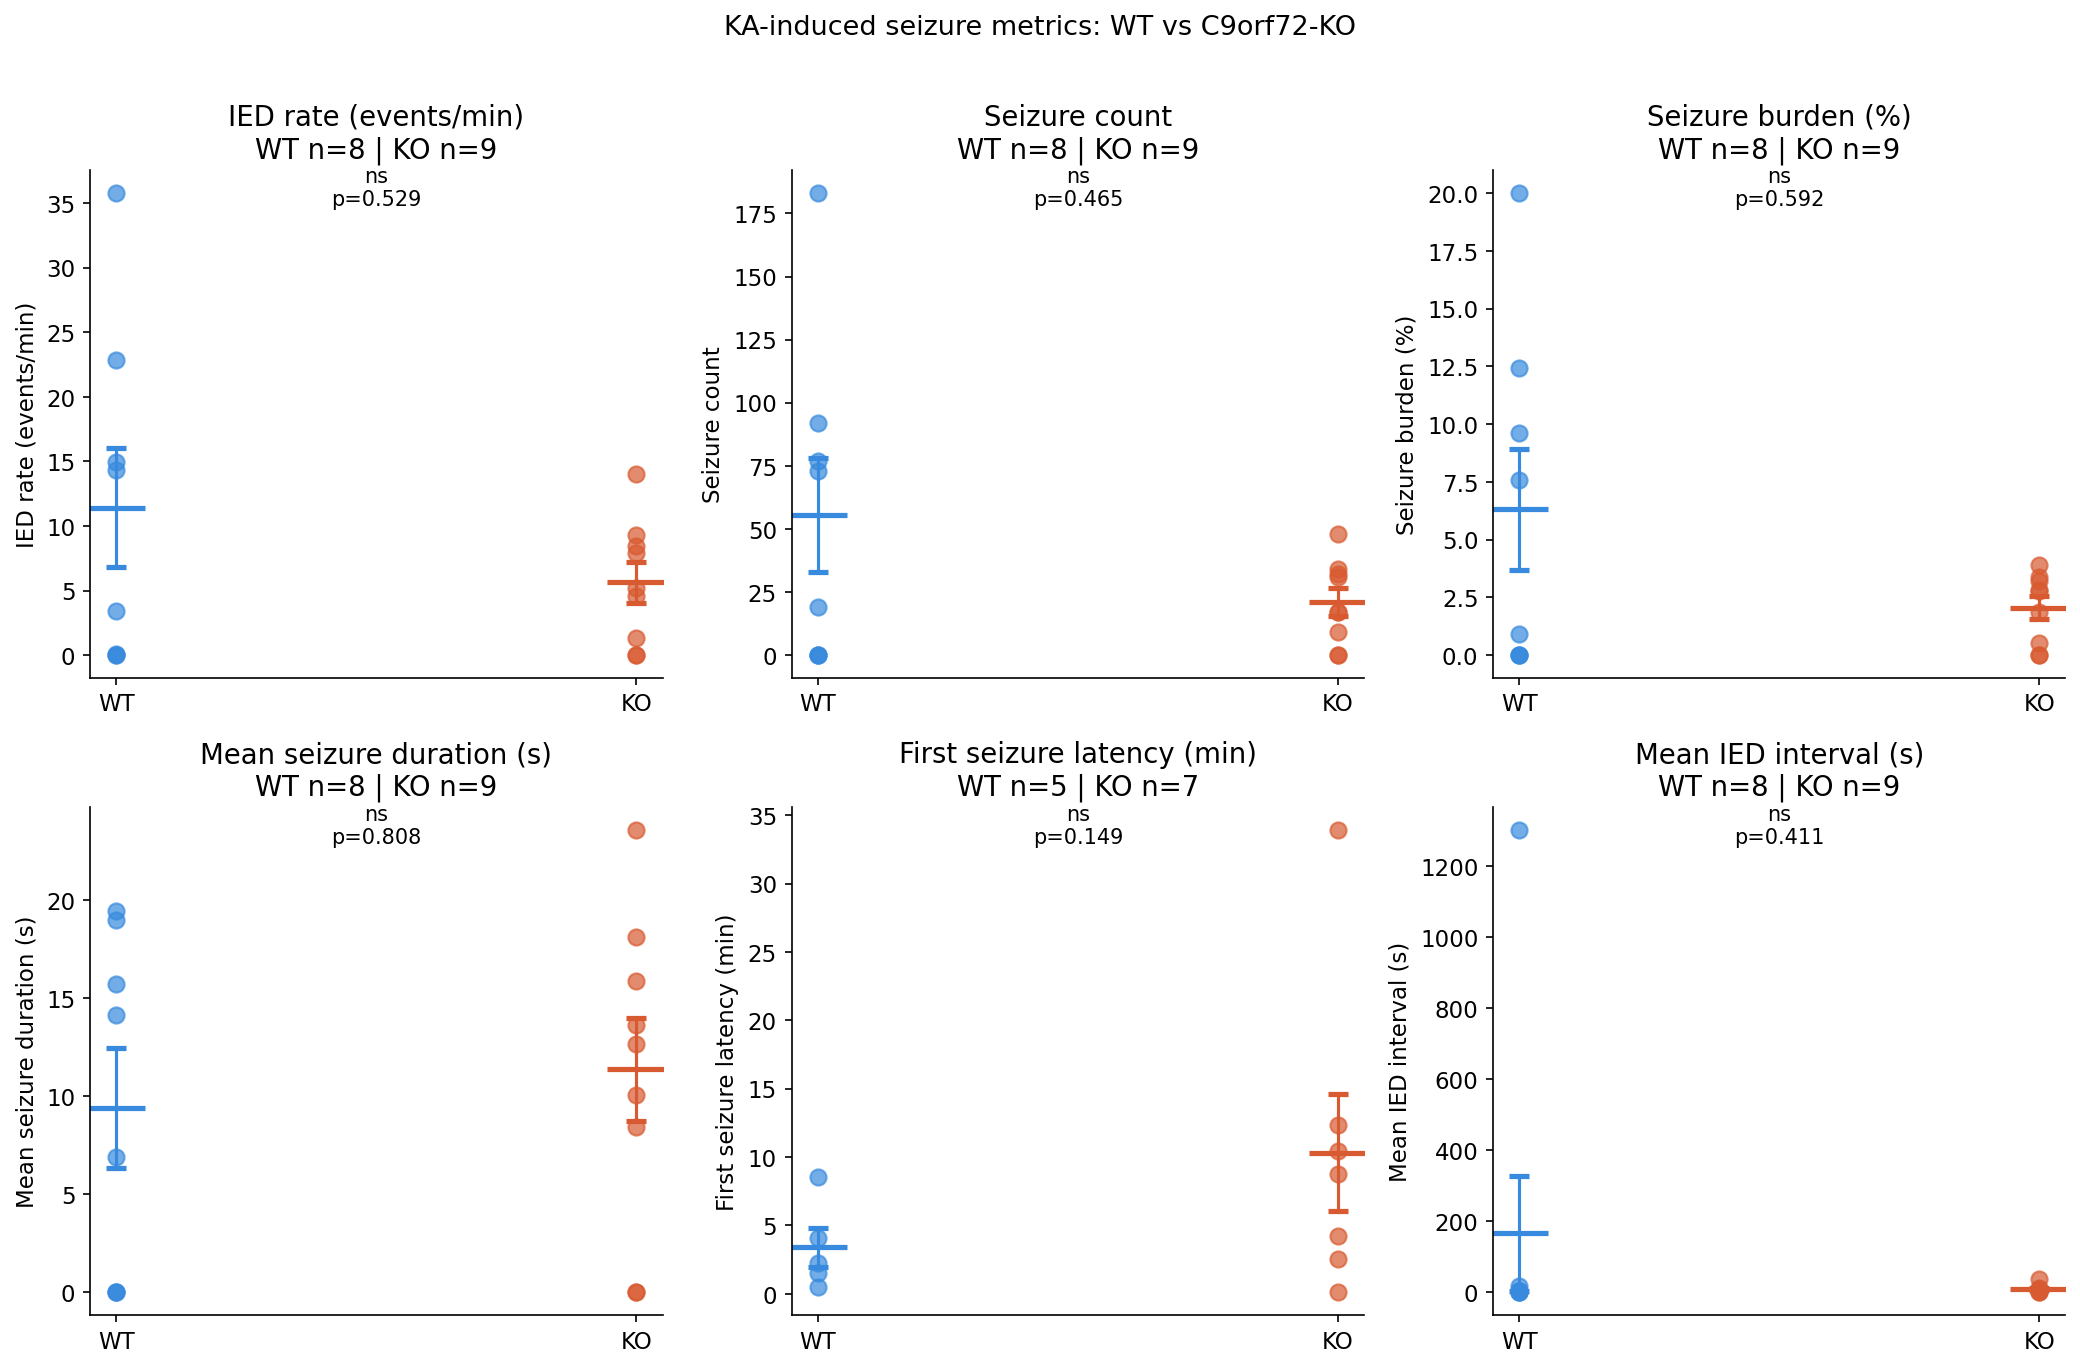

Saved: seizure_metrics_all.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for ax, (col, label) in zip(axes, metrics_to_compare):
    wt_vals = summary_wt[col].dropna()
    ko_vals = summary_ko[col].dropna()
    if len(wt_vals) < 2 or len(ko_vals) < 2:
        ax.set_visible(False)
        continue
    plot_group_comparison(
        ax, wt_vals, ko_vals,
        ylabel=label,
        title=f"{label}\nWT n={len(wt_vals)} | KO n={len(ko_vals)}"
    )

fig.suptitle("KA-induced seizure metrics: WT vs C9orf72-KO", fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "seizure_metrics_all.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: seizure_metrics_all.png")

## 6. Seizure timeline — when do seizures occur?

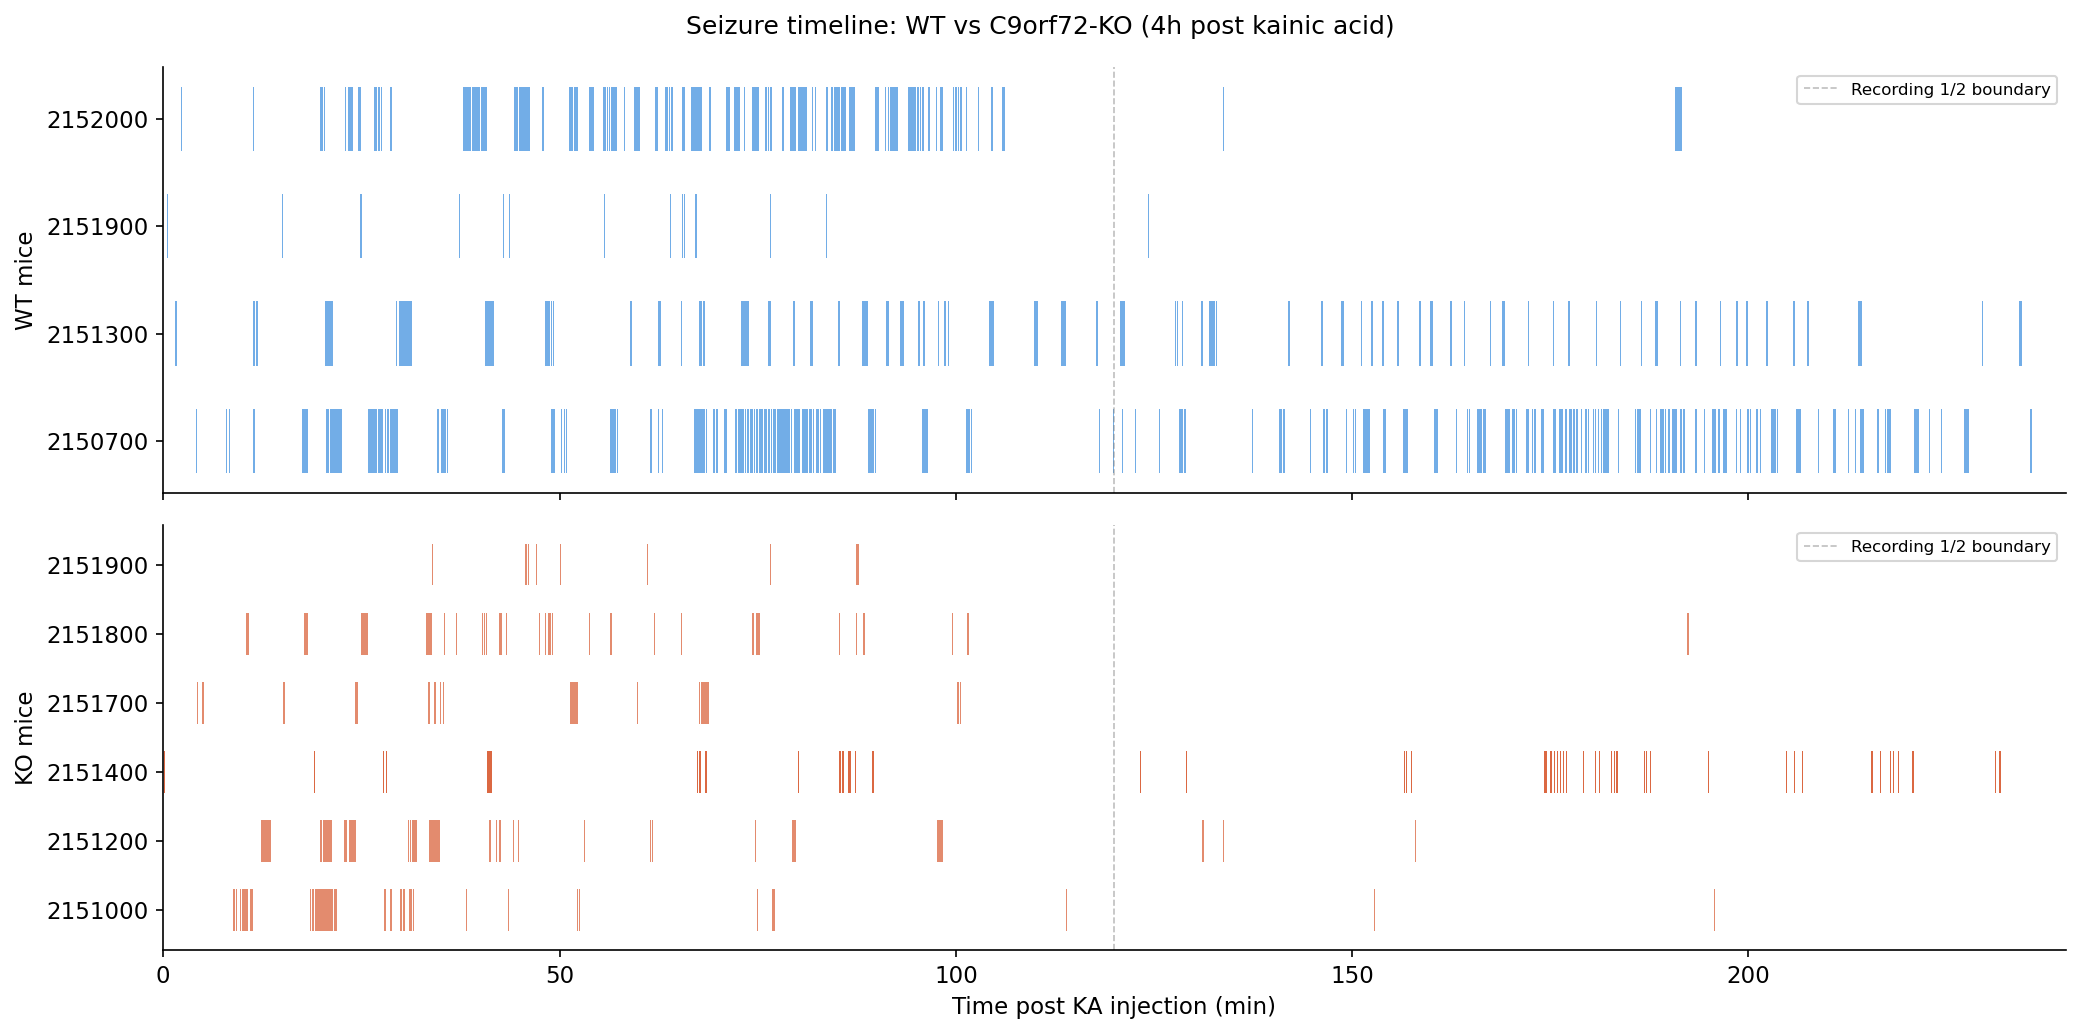

Saved: seizure_timeline.png


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, summary, details, group, color in [
    (axes[0], summary_wt, details_wt, "WT", COLORS["WT"]),
    (axes[1], summary_ko, details_ko, "KO", COLORS["KO"]),
]:
    for i, row in summary.iterrows():
        mouse_id = row["mouse_id"]
        seizures = details[mouse_id]["seizures"]
        if len(seizures) > 0:
            for _, szr in seizures.iterrows():
                ax.barh(
                    mouse_id,
                    szr["duration_s"] / 60,
                    left=szr["onset_s"] / 60,
                    color=color, alpha=0.7, height=0.6
                )

    ax.set_ylabel(f"{group} mice")
    ax.set_xlim(0, 240)
    ax.axvline(120, color="gray", lw=0.8, ls="--", alpha=0.5, label="Recording 1/2 boundary")
    ax.legend(fontsize=8)

axes[1].set_xlabel("Time post KA injection (min)")
fig.suptitle("Seizure timeline: WT vs C9orf72-KO (4h post kainic acid)", fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "seizure_timeline.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: seizure_timeline.png")

## 7. IED rate over time — does it change across the 4h recording?

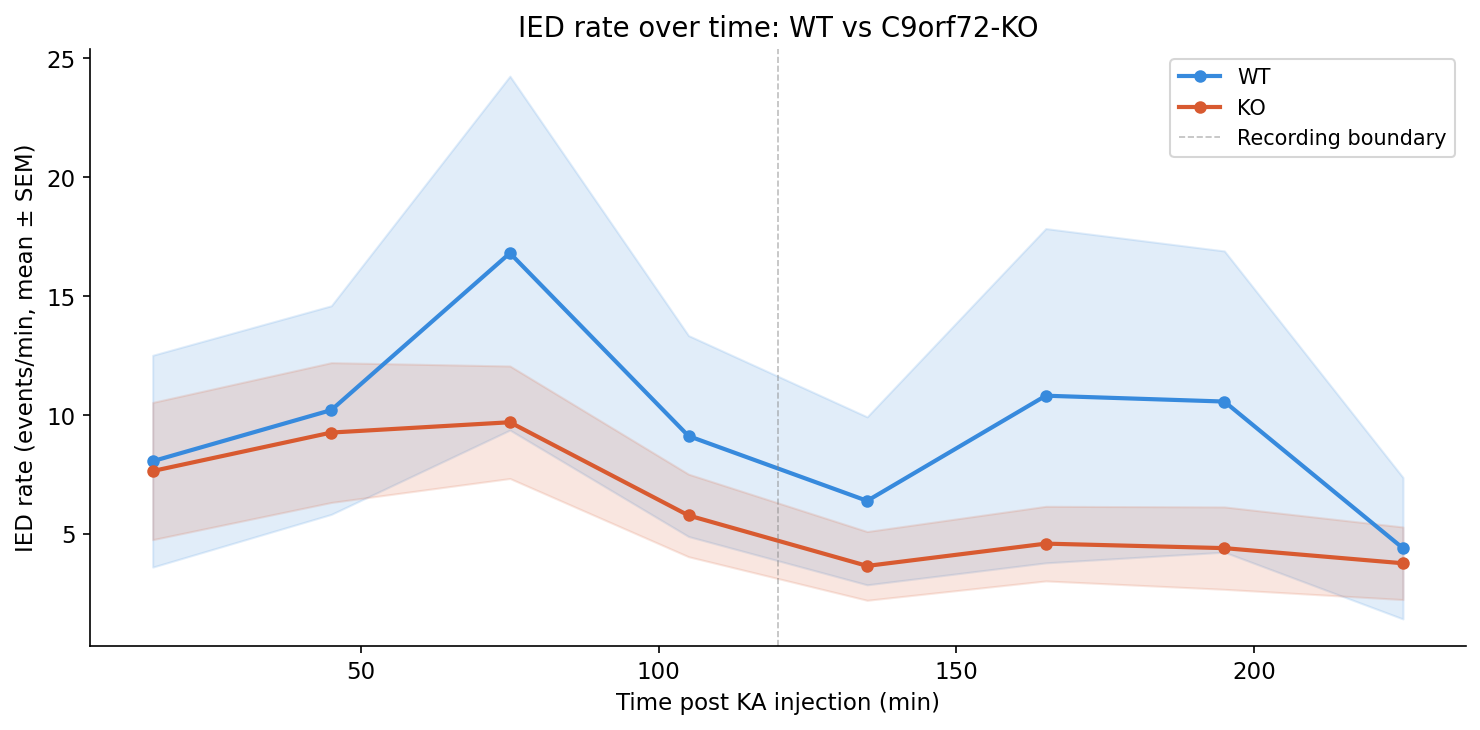

Saved: ied_rate_over_time.png


In [10]:
bin_size_min = 30
bins = np.arange(0, 241, bin_size_min)
bin_centers = (bins[:-1] + bins[1:]) / 2

fig, ax = plt.subplots(figsize=(10, 5))

for summary, details, group, color in [
    (summary_wt, details_wt, "WT", COLORS["WT"]),
    (summary_ko, details_ko, "KO", COLORS["KO"]),
]:
    all_rates = []
    for mouse_id in summary["mouse_id"]:
        ieds = details[mouse_id]["ieds"]
        ied_times_min = ieds["time_s"].values / 60
        counts, _ = np.histogram(ied_times_min, bins=bins)
        rates = counts / bin_size_min
        all_rates.append(rates)

    if all_rates:
        rates_array = np.array(all_rates)
        mean_rates = rates_array.mean(axis=0)
        sem_rates = rates_array.std(axis=0) / np.sqrt(len(all_rates))
        ax.plot(bin_centers, mean_rates, color=color, lw=2, marker="o", markersize=5, label=group)
        ax.fill_between(bin_centers, mean_rates - sem_rates, mean_rates + sem_rates,
                        color=color, alpha=0.15)

ax.axvline(120, color="gray", lw=0.8, ls="--", alpha=0.5, label="Recording boundary")
ax.set_xlabel("Time post KA injection (min)")
ax.set_ylabel("IED rate (events/min, mean ± SEM)")
ax.set_title("IED rate over time: WT vs C9orf72-KO")
ax.legend(fontsize=10)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "ied_rate_over_time.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ied_rate_over_time.png")

## 8. Save processed data

In [11]:
summary_all = pd.concat([summary_wt, summary_ko], ignore_index=True)
summary_all.to_csv(os.path.join(DATA_DIR, "seizure_metrics_per_mouse.csv"), index=False)
print(f"Saved: seizure_metrics_per_mouse.csv ({len(summary_all)} rows)")
print(f"Columns: {list(summary_all.columns)}")

Saved: seizure_metrics_per_mouse.csv (17 rows)
Columns: ['n_ieds', 'ied_rate_per_min', 'mean_ied_interval_s', 'n_seizures', 'total_seizure_dur_s', 'mean_seizure_dur_s', 'seizure_burden_pct', 'first_seizure_min', 'recording_duration_min', 'mouse_id', 'baseline_mV', 'threshold_mV', 'group']


## 9. Key findings

| Metric | WT (n=8) | KO (n=9) | p-value | sig |
|--------|----------|----------|---------|-----|
| IED rate (events/min) | 11.4±4.6 | 5.6±1.6 | 0.529 | ns |
| Seizure count | 55.5±22.7 | 20.9±5.5 | 0.465 | ns |
| Seizure burden (%) | 6.3±2.6 | 2.1±0.5 | 0.592 | ns |
| Mean seizure duration (s) | 9.4±3.1 | 11.4±2.6 | 0.808 | ns |
| First seizure latency (min) | 3.4±1.4 | 10.3±4.3 | 0.149 | ns |
| Mean IED interval (s) | 166.2±162.0 | 9.5±3.7 | 0.411 | ns |

**Biological interpretation:**  
C9orf72-KO mice show no significant difference from WT in any measure of 
kainic acid-induced seizure activity at 4 months of age. Numerically, WT 
mice showed higher IED rates, seizure counts, and seizure burden than KO, 
though none reached significance due to high inter-animal variability. 
This indicates that C9orf72 loss does not increase acute seizure 
susceptibility — the mechanism of network dysfunction in this model 
appears to be progressive rather than acute, consistent with the 
longitudinal spectral findings showing theta power divergence at 3 and 
12 months.

---
*Statistical test: Mann-Whitney U (two-sided)*  
*Statistical unit: one mouse (2 × 2h recordings averaged)*  
*Recording: 4h post kainic acid injection*  
*No animals excluded*